<a href="https://colab.research.google.com/github/saverin0/bavaria-wheat-sentinel2-oco2/blob/main/notebooks/03_oco2_sif_sentinel2_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 · OCO-2 SIF footprints × Sentinel-2 B4/B8 (optional)

For every OCO-2 solar-induced fluorescence (SIF) sounding footprint over Bavaria, extract the mean
Sentinel-2 red (B4) and NIR (B8) reflectance from the monthly WASP composite of the same year/month,
then compute NDVI and NIRv per footprint. This allows comparing satellite SIF with reflectance-based
vegetation indices. Outputs shown are from the completed run (151,793 footprints).

**Inputs**
- `{DRIVE_BASE}/WASP_Cache/` from notebook 01
- `{DRIVE_BASE}/oco2_sif.parquet`: OCO-2 SIF Lite soundings (see README). Required columns:
  `Delta_date` (YYYY-MM-DD string), `Lon_corner1..4`, `Lat_corner1..4`, `Daily_SIF_740nm`;
  optional `Delta_Time`, `Quality_Flag`, `NUTS_NAME`.

**Method**
- Footprint polygons are built from the four corner coordinates.
- Footprints inside a single tile: one `exactextract` call per (year, month, tile), in parallel.
- Footprints crossing tile boundaries: clipped per tile and combined by area weighting.
- Polygons are reprojected to each tile's UTM CRS before extraction.

Expected runtime: about 45–60 minutes on a High-RAM Colab runtime (CPU only).


In [ ]:
# Cell 1: Install dependencies
%%capture
!pip install -q polars geopandas rasterio shapely pyproj tqdm joblib pyarrow exactextract

In [ ]:
# Cell 2: Mount Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Not running in Colab: skipping Drive mount')

Mounted at /content/drive


In [ ]:
# Cell 3: Configuration
import os
from pathlib import Path
from dataclasses import dataclass

@dataclass
class Config:
    # Project folder (same as notebooks 01/02). Override with WHEAT_DRIVE_BASE when running locally.
    BASE_PATH: Path = Path(os.environ.get('WHEAT_DRIVE_BASE', '/content/drive/MyDrive/Capstone Project'))
    PARQUET_PATH: Path = None
    WASP_CACHE: Path = None
    OUTPUT_DIR: Path = None
    MONTH_NAMES: dict = None
    N_JOBS: int = 4

    def __post_init__(self):
        self.PARQUET_PATH = self.BASE_PATH / 'oco2_sif.parquet'
        self.WASP_CACHE = self.BASE_PATH / 'WASP_Cache'
        self.OUTPUT_DIR = self.BASE_PATH / 'outputs'
        self.MONTH_NAMES = {
            3: '03_March',
            4: '04_April',
            5: '05_May',
            6: '06_June'
        }

config = Config()
print(f"Base path: {config.BASE_PATH}")

Base path: /content/drive/MyDrive/Capstone Project


In [ ]:
# Cell 4: Imports and clean outputs
import numpy as np
import polars as pl
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import transform_bounds
from shapely.geometry import Polygon, box
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from exactextract import exact_extract
import warnings
import gc
import re
import shutil

warnings.filterwarnings('ignore')

# Optionally wipe previous outputs (deletes the whole folder - keep False unless you mean it)
CLEAR_OLD_OUTPUTS = False
if CLEAR_OLD_OUTPUTS and config.OUTPUT_DIR.exists():
    shutil.rmtree(config.OUTPUT_DIR)
    print(f"🗑️ Cleared old outputs")
config.OUTPUT_DIR.mkdir(exist_ok=True)
print(f"📁 Created: {config.OUTPUT_DIR}")
print(f"✅ Imports complete")

🗑️ Cleared old outputs
📁 Created: /content/drive/MyDrive/Capstone Project/outputs
✅ Imports complete


In [ ]:
# Cell 5: Load parquet with polars
print("Loading OCO-2 SIF data...")

df_pl = pl.read_parquet(config.PARQUET_PATH)
print(f"   Total rows: {len(df_pl):,}")

# Parse date and filter
df_pl = df_pl.with_columns([
    pl.col('Delta_date').str.to_date().alias('Delta_date_parsed')
]).with_columns([
    pl.col('Delta_date_parsed').dt.year().alias('year'),
    pl.col('Delta_date_parsed').dt.month().alias('month')
]).filter(
    pl.col('month').is_in([3, 4, 5, 6])
)

print(f"   Filtered to months 3-6: {len(df_pl):,}")
df = df_pl.to_pandas()
print(f"✅ Loaded {len(df):,} rows")

Loading OCO-2 SIF data...
   Total rows: 206,643
   Filtered to months 3-6: 151,827
✅ Loaded 151,827 rows


In [ ]:
# Cell 6: Create polygons
def create_polygons_fast(df):
    n = len(df)
    lon1, lon2 = df['Lon_corner1'].values, df['Lon_corner2'].values
    lon3, lon4 = df['Lon_corner3'].values, df['Lon_corner4'].values
    lat1, lat2 = df['Lat_corner1'].values, df['Lat_corner2'].values
    lat3, lat4 = df['Lat_corner3'].values, df['Lat_corner4'].values

    polygons = [None] * n
    for i in tqdm(range(n), desc="Creating polygons"):
        try:
            coords = [(lon1[i], lat1[i]), (lon2[i], lat2[i]),
                      (lon3[i], lat3[i]), (lon4[i], lat4[i]), (lon1[i], lat1[i])]
            poly = Polygon(coords)
            polygons[i] = poly if poly.is_valid else poly.buffer(0)
        except:
            pass
    return polygons

print("Creating polygons...")
df['geometry'] = create_polygons_fast(df)
df = df[df['geometry'].notna()].copy()
gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326').reset_index(drop=True)
gdf['poly_id'] = gdf.index
print(f"✅ Created {len(gdf):,} polygons")

Creating polygons...


Creating polygons:   0%|          | 0/151827 [00:00<?, ?it/s]

✅ Created 151,827 polygons


In [ ]:
# Cell 7: Build tile index with CRS info
def build_tile_index(wasp_cache):
    tiles = {}
    year_folders = [f for f in wasp_cache.iterdir() if f.is_dir() and f.name.isdigit()]
    print(f"Scanning {len(year_folders)} year folders...")

    for year_folder in sorted(year_folders):
        for month_folder in year_folder.iterdir():
            if not month_folder.is_dir():
                continue
            for tif_file in month_folder.glob('*_B4.tif'):
                match = re.search(r'_T(\d{2}[A-Z]{3})_', tif_file.name)
                if match:
                    tile_id = match.group(1)
                    if tile_id not in tiles:
                        with rasterio.open(tif_file) as src:
                            bounds_wgs84 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
                            tiles[tile_id] = {
                                'tile_id': tile_id,
                                'geometry': box(*bounds_wgs84),
                                'native_crs': str(src.crs)  # Store CRS for reprojection
                            }

    tile_gdf = gpd.GeoDataFrame(list(tiles.values()), crs='EPSG:4326')
    print(f"✅ Found {len(tile_gdf)} tiles")
    return tile_gdf

tile_index = build_tile_index(config.WASP_CACHE)
print(f"   CRS types: {tile_index['native_crs'].unique()}")

Scanning 8 year folders...
✅ Found 29 tiles
   CRS types: ['EPSG:32633' 'EPSG:32632']


In [ ]:
# Cell 8: Assign polygons to tiles
print("Assigning polygons to tiles...")

joined = gpd.sjoin(gdf[['poly_id', 'geometry']],
                   tile_index[['tile_id', 'geometry']],
                   how='left', predicate='intersects')

tile_groups = joined.groupby('poly_id')['tile_id'].apply(list).reset_index()
tile_groups.columns = ['poly_id', 'tile_ids']

gdf = gdf.merge(tile_groups, on='poly_id', how='left')
gdf['tile_ids'] = gdf['tile_ids'].apply(lambda x: x if isinstance(x, list) else [])
gdf['n_tiles'] = gdf['tile_ids'].apply(len)
gdf['primary_tile'] = gdf['tile_ids'].apply(lambda x: x[0] if len(x) == 1 else None)

gdf_single = gdf[gdf['n_tiles'] == 1].copy()
gdf_multi = gdf[gdf['n_tiles'] > 1].copy()

print(f"\n📊 Results:")
print(f"   Single-tile: {len(gdf_single):,} ({len(gdf_single)/len(gdf)*100:.1f}%)")
print(f"   Multi-tile:  {len(gdf_multi):,} ({len(gdf_multi)/len(gdf)*100:.1f}%)")

Assigning polygons to tiles...

📊 Results:
   Single-tile: 112,332 (74.0%)
   Multi-tile:  39,495 (26.0%)


In [ ]:
# Cell 9: Helper function

def get_raster_path(wasp_cache, year, month, tile_id, band, month_names):
    """Find raster file path."""
    month_folder = month_names.get(int(month))
    if not month_folder:
        return None
    folder = wasp_cache / str(int(year)) / month_folder
    if not folder.exists():
        return None
    files = list(folder.glob(f'*_T{tile_id}_*_B{band}.tif'))
    return files[0] if files else None

print("✅ Helper function defined")

✅ Helper function defined


In [ ]:
# Cell 10: FAST Single-tile extraction with exactextract + CRS reprojection

def extract_single_tile_batch_fast(gdf_group, wasp_cache, tile_index, month_names):
    """
    Extract B4/B8 using exactextract.
    Key: Reproject polygons to raster CRS before extraction!
    """
    if len(gdf_group) == 0:
        return pd.DataFrame()

    year = gdf_group['year'].iloc[0]
    month = gdf_group['month'].iloc[0]
    tile_id = gdf_group['primary_tile'].iloc[0]

    b4_path = get_raster_path(wasp_cache, year, month, tile_id, 4, month_names)
    b8_path = get_raster_path(wasp_cache, year, month, tile_id, 8, month_names)

    if not b4_path or not b8_path:
        return pd.DataFrame({
            'poly_id': gdf_group['poly_id'].values,
            'B4': [None] * len(gdf_group),
            'B8': [None] * len(gdf_group)
        })

    try:
        # Get raster CRS
        with rasterio.open(b4_path) as src:
            raster_crs = src.crs

        # Create GeoDataFrame and REPROJECT to raster CRS
        gdf_extract = gpd.GeoDataFrame(
            {'poly_id': gdf_group['poly_id'].values},
            geometry=gdf_group.geometry.values,
            crs='EPSG:4326'
        ).to_crs(raster_crs)  # <-- KEY FIX!

        # Extract B4 - all polygons in one C++ call!
        b4_results = exact_extract(
            str(b4_path),
            gdf_extract,
            ['mean'],
            output='pandas'
        )

        # Extract B8
        b8_results = exact_extract(
            str(b8_path),
            gdf_extract,
            ['mean'],
            output='pandas'
        )

        return pd.DataFrame({
            'poly_id': gdf_group['poly_id'].values,
            'B4': b4_results['mean'].values,
            'B8': b8_results['mean'].values
        })

    except Exception as e:
        return pd.DataFrame({
            'poly_id': gdf_group['poly_id'].values,
            'B4': [None] * len(gdf_group),
            'B8': [None] * len(gdf_group)
        })

print("✅ Fast extraction function defined (exactextract + CRS fix)")

✅ Fast extraction function defined (exactextract + CRS fix)


In [ ]:
# Cell 11: Test extraction on one group
print("Testing extraction on one group...")

groups = list(gdf_single.groupby(['year', 'month', 'primary_tile']))
(year, month, tile_id), test_group = groups[0]

print(f"   Group: {year}/{month}/{tile_id}")
print(f"   Polygons: {len(test_group)}")

test_result = extract_single_tile_batch_fast(test_group, config.WASP_CACHE, tile_index, config.MONTH_NAMES)
print(f"\n   Result sample:")
print(test_result.head())
print(f"\n   Valid B4: {test_result['B4'].notna().sum()} / {len(test_result)}")
print(f"   B4 range: {test_result['B4'].min():.1f} - {test_result['B4'].max():.1f}")

Testing extraction on one group...
   Group: 2017/3/32TNT
   Polygons: 82

   Result sample:
   poly_id          B4           B8
0     1744  647.051964  2459.946180
1     1752  531.455812  3194.213754
2     1753  567.669578  2636.351113
3     1760  393.407728  3412.699726
4     1761  584.716166  2510.857241

   Valid B4: 82 / 82
   B4 range: 226.6 - 647.1


In [ ]:
# Cell 12: Multi-tile extraction function (exactextract + area-weighted + CRS fix)

def extract_multi_tile_fast(gdf_multi, tile_index, wasp_cache, month_names, n_jobs=4):
    """Extract B4/B8 for multi-tile polygons with area-weighting using exactextract."""
    if len(gdf_multi) == 0:
        return pd.DataFrame(columns=['poly_id', 'B4', 'B8'])

    print("Step 1: Pre-clipping polygons to tile boundaries...")

    clipped_pieces = []
    for idx, row in tqdm(gdf_multi.iterrows(), total=len(gdf_multi), desc="Clipping"):
        poly = row.geometry
        for tile_id in row['tile_ids']:
            tile_row = tile_index[tile_index['tile_id'] == tile_id]
            if len(tile_row) == 0:
                continue
            try:
                clipped = poly.intersection(tile_row.iloc[0].geometry)
                if not clipped.is_empty and clipped.area > 0:
                    clipped_pieces.append({
                        'poly_id': row['poly_id'],
                        'tile_id': tile_id,
                        'year': row['year'],
                        'month': row['month'],
                        'geometry': clipped,
                        'clip_area': clipped.area,
                        'native_crs': tile_row.iloc[0]['native_crs']  # Store tile CRS
                    })
            except:
                pass

    gdf_clips = gpd.GeoDataFrame(clipped_pieces, crs='EPSG:4326')
    print(f"   Created {len(gdf_clips):,} clipped pieces")

    print("\nStep 2: Batch extraction with exactextract...")
    groups = list(gdf_clips.groupby(['year', 'month', 'tile_id']))
    print(f"   Groups: {len(groups)}")

    def process_clip_group(group_data):
        (year, month, tile_id), group_df = group_data
        b4_path = get_raster_path(wasp_cache, year, month, tile_id, 4, month_names)
        b8_path = get_raster_path(wasp_cache, year, month, tile_id, 8, month_names)

        if not b4_path or not b8_path:
            result = group_df[['poly_id', 'clip_area']].copy()
            result['B4_clip'] = None
            result['B8_clip'] = None
            return result

        try:
            # Get raster CRS and reproject
            with rasterio.open(b4_path) as src:
                raster_crs = src.crs

            gdf_extract = gpd.GeoDataFrame(
                group_df[['poly_id', 'clip_area']].copy(),
                geometry=group_df.geometry.values,
                crs='EPSG:4326'
            ).to_crs(raster_crs)  # <-- KEY FIX!

            b4_results = exact_extract(str(b4_path), gdf_extract, ['mean'], output='pandas')
            b8_results = exact_extract(str(b8_path), gdf_extract, ['mean'], output='pandas')

            result = group_df[['poly_id', 'clip_area']].copy()
            result['B4_clip'] = b4_results['mean'].values
            result['B8_clip'] = b8_results['mean'].values
            return result

        except Exception as e:
            result = group_df[['poly_id', 'clip_area']].copy()
            result['B4_clip'] = None
            result['B8_clip'] = None
            return result

    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(process_clip_group)(g) for g in groups
    )

    clips_with_values = pd.concat(results, ignore_index=True)

    print("\nStep 3: Area-weighted averaging...")

    def weighted_avg(group):
        valid = group.dropna(subset=['B4_clip', 'B8_clip'])
        if len(valid) == 0:
            return pd.Series({'B4': None, 'B8': None})
        total_area = valid['clip_area'].sum()
        b4 = (valid['B4_clip'] * valid['clip_area']).sum() / total_area
        b8 = (valid['B8_clip'] * valid['clip_area']).sum() / total_area
        return pd.Series({'B4': b4, 'B8': b8})

    final = clips_with_values.groupby('poly_id').apply(weighted_avg).reset_index()
    return final

print("✅ Multi-tile extraction function defined")

✅ Multi-tile extraction function defined


In [ ]:
# Cell 13: PHASE 1 - Single-tile extraction (FAST!)

print("="*60)
print("PHASE 1: Single-tile extraction (exactextract)")
print("="*60)
print(f"\nProcessing {len(gdf_single):,} single-tile polygons...")

groups = list(gdf_single.groupby(['year', 'month', 'primary_tile']))
print(f"   Groups: {len(groups)}")

def process_single_group(group_data):
    _, group_df = group_data
    return extract_single_tile_batch_fast(group_df, config.WASP_CACHE, tile_index, config.MONTH_NAMES)

print(f"\n🚀 Running parallel extraction ({config.N_JOBS} workers)...")
single_results = Parallel(n_jobs=config.N_JOBS, verbose=10)(
    delayed(process_single_group)(g) for g in groups
)

single_results_df = pd.concat(single_results, ignore_index=True)
gdf_single = gdf_single.merge(single_results_df, on='poly_id', how='left')

successful = gdf_single['B4'].notna().sum()
print(f"\n✅ Phase 1 complete!")
print(f"   Successful: {successful:,} / {len(gdf_single):,} ({successful/len(gdf_single)*100:.1f}%)")

PHASE 1: Single-tile extraction (exactextract)

Processing 112,332 single-tile polygons...
   Groups: 307

🚀 Running parallel extraction (4 workers)...


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   49.7s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.1min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  1.9min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  2.4min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  3.3min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  5.1min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  6.5min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  7.6min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  8.6min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed: 10.2min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed: 11.8min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed: 14.1min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 16.0min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed: 19.1min
[Parallel(


✅ Phase 1 complete!
   Successful: 112,308 / 112,332 (100.0%)


In [ ]:
# Cell 14: PHASE 2 - Multi-tile extraction

print("="*60)
print("PHASE 2: Multi-tile extraction (exactextract + area-weighted)")
print("="*60)
print(f"\nProcessing {len(gdf_multi):,} multi-tile polygons...")

if len(gdf_multi) > 0:
    multi_results_df = extract_multi_tile_fast(
        gdf_multi, tile_index, config.WASP_CACHE,
        config.MONTH_NAMES, n_jobs=config.N_JOBS
    )
    gdf_multi = gdf_multi.merge(multi_results_df, on='poly_id', how='left')

    successful = gdf_multi['B4'].notna().sum()
    print(f"\n✅ Phase 2 complete!")
    print(f"   Successful: {successful:,} / {len(gdf_multi):,} ({successful/len(gdf_multi)*100:.1f}%)")
else:
    print("   No multi-tile polygons.")

gc.collect()

PHASE 2: Multi-tile extraction (exactextract + area-weighted)

Processing 39,495 multi-tile polygons...
Step 1: Pre-clipping polygons to tile boundaries...


Clipping:   0%|          | 0/39495 [00:00<?, ?it/s]

   Created 86,895 clipped pieces

Step 2: Batch extraction with exactextract...
   Groups: 443


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:   53.7s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:  1.5min
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:  2.0min
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:  2.7min
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:  3.6min
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:  4.2min
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:  5.5min
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:  6.5min
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:  7.9min
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:  9.4min
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed: 11.1min
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed: 12.5min
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed: 14.3min
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed: 16.1min
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed: 18.6min
[Parallel(


Step 3: Area-weighted averaging...

✅ Phase 2 complete!
   Successful: 39,485 / 39,495 (100.0%)


0

In [ ]:
# Cell 15: Combine results

print("Combining results...")

if len(gdf_multi) > 0:
    gdf_combined = pd.concat([gdf_single, gdf_multi], ignore_index=True)
else:
    gdf_combined = gdf_single.copy()

gdf_combined = gdf_combined.sort_values('poly_id').reset_index(drop=True)
print(f"✅ Combined: {len(gdf_combined):,} polygons")
print(f"   With valid B4/B8: {gdf_combined['B4'].notna().sum():,}")

Combining results...
✅ Combined: 151,827 polygons
   With valid B4/B8: 151,793


In [ ]:
# Cell 16: Calculate NDVI and NIRv

print("Calculating vegetation indices...")

b4 = gdf_combined['B4'].values.astype(float)
b8 = gdf_combined['B8'].values.astype(float)

with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = np.where((b8 + b4) != 0, (b8 - b4) / (b8 + b4), np.nan)

nirv = ndvi * b8
ndvi = np.clip(ndvi, -1, 1)

gdf_combined['NDVI'] = ndvi
gdf_combined['NIRv'] = nirv

print(f"\n✅ Calculated NDVI and NIRv")
print(f"   NDVI: mean={np.nanmean(ndvi):.4f}, range=[{np.nanmin(ndvi):.4f}, {np.nanmax(ndvi):.4f}]")
print(f"   NIRv: mean={np.nanmean(nirv):.2f}")

Calculating vegetation indices...

✅ Calculated NDVI and NIRv
   NDVI: mean=0.6123, range=[-0.9808, 0.9995]
   NIRv: mean=1656.54


In [ ]:
# Cell 17: Prepare final dataset

gdf_final = gdf_combined.dropna(subset=['B4', 'B8', 'NDVI']).copy()

keep_cols = ['Delta_date', 'year', 'month', 'geometry', 'Daily_SIF_740nm',
             'B4', 'B8', 'NDVI', 'NIRv', 'n_tiles', 'tile_ids']

for col in ['Delta_Time', 'NUTS_NAME', 'Quality_Flag']:
    if col in gdf_final.columns:
        keep_cols.insert(3, col)

gdf_final = gdf_final[[c for c in keep_cols if c in gdf_final.columns]]
gdf_final = gpd.GeoDataFrame(gdf_final, geometry='geometry', crs='EPSG:4326')

print(f"✅ Final dataset: {len(gdf_final):,} rows")
print(f"   Single-tile: {(gdf_final['n_tiles'] == 1).sum():,}")
print(f"   Multi-tile:  {(gdf_final['n_tiles'] > 1).sum():,}")

✅ Final dataset: 151,793 rows
   Single-tile: 112,308
   Multi-tile:  39,485


In [ ]:
# Cell 18: Save results

gdf_final['tile_ids_str'] = gdf_final['tile_ids'].apply(
    lambda x: ','.join(x) if isinstance(x, list) else ''
)
gdf_save = gdf_final.drop(columns=['tile_ids'])

# GeoParquet
parquet_path = config.OUTPUT_DIR / 'oco2_sif_with_sentinel2.parquet'
gdf_save.to_parquet(parquet_path)
print(f"✅ {parquet_path}")

# CSV
csv_path = config.OUTPUT_DIR / 'oco2_sif_with_sentinel2.csv'
gdf_save.drop(columns=['geometry']).to_csv(csv_path, index=False)
print(f"✅ {csv_path}")

# GeoPackage
gpkg_path = config.OUTPUT_DIR / 'oco2_sif_with_sentinel2.gpkg'
gdf_save.to_file(gpkg_path, driver='GPKG')
print(f"✅ {gpkg_path}")

print(f"\n📁 All saved to: {config.OUTPUT_DIR}")

✅ /content/drive/MyDrive/Capstone Project/outputs/oco2_sif_with_sentinel2.parquet
✅ /content/drive/MyDrive/Capstone Project/outputs/oco2_sif_with_sentinel2.csv
✅ /content/drive/MyDrive/Capstone Project/outputs/oco2_sif_with_sentinel2.gpkg

📁 All saved to: /content/drive/MyDrive/Capstone Project/outputs


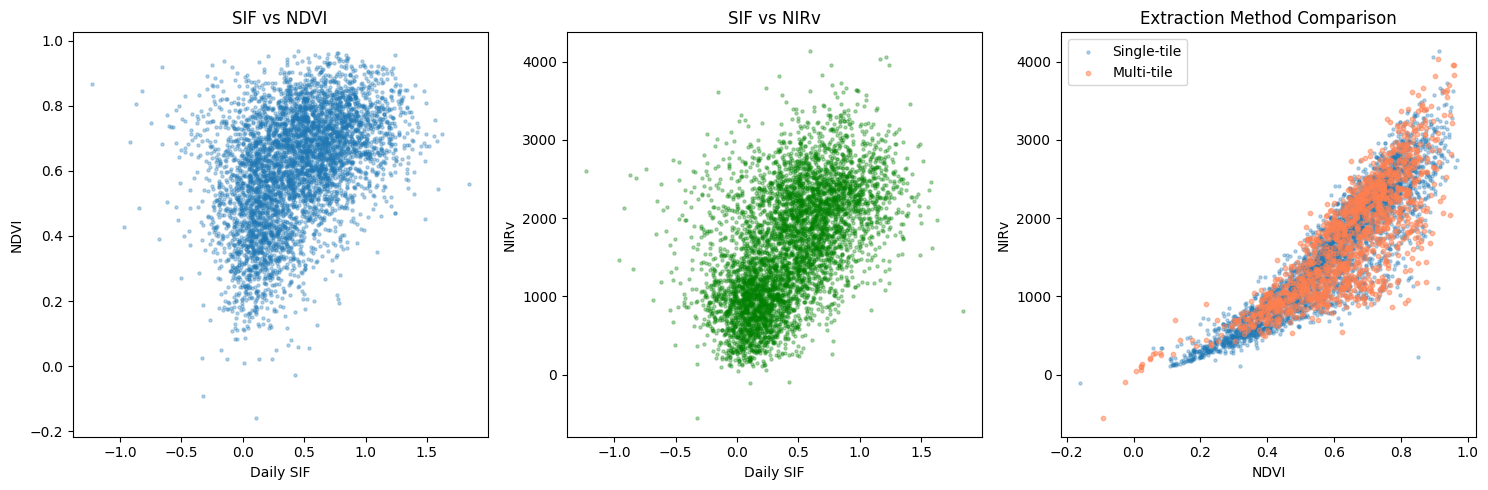

In [ ]:
# Cell 19: Visualization

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample = gdf_final.sample(min(5000, len(gdf_final)))

axes[0].scatter(sample['Daily_SIF_740nm'], sample['NDVI'], alpha=0.3, s=5)
axes[0].set_xlabel('Daily SIF'); axes[0].set_ylabel('NDVI'); axes[0].set_title('SIF vs NDVI')

axes[1].scatter(sample['Daily_SIF_740nm'], sample['NIRv'], alpha=0.3, s=5, c='green')
axes[1].set_xlabel('Daily SIF'); axes[1].set_ylabel('NIRv'); axes[1].set_title('SIF vs NIRv')

single = sample[sample['n_tiles'] == 1]
multi = sample[sample['n_tiles'] > 1]
axes[2].scatter(single['NDVI'], single['NIRv'], alpha=0.3, s=5, label='Single-tile')
axes[2].scatter(multi['NDVI'], multi['NIRv'], alpha=0.5, s=10, c='coral', label='Multi-tile')
axes[2].set_xlabel('NDVI'); axes[2].set_ylabel('NIRv'); axes[2].legend()
axes[2].set_title('Extraction Method Comparison')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / 'results.png', dpi=150)
plt.show()

In [ ]:
# Cell 20: Summary

print("="*60)
print("SUMMARY")
print("="*60)
print(f"\nTotal footprints: {len(gdf_final):,}")
print(f"Years: {gdf_final['year'].min()} - {gdf_final['year'].max()}")
print(f"Months: {gdf_final['month'].min()} - {gdf_final['month'].max()}")

print(f"\nExtraction methods:")
print(f"   Single-tile: {(gdf_final['n_tiles'] == 1).sum():,}")
print(f"   Multi-tile:  {(gdf_final['n_tiles'] > 1).sum():,}")

print(f"\nCorrelations:")
print(f"   SIF vs NDVI: {gdf_final['Daily_SIF_740nm'].corr(gdf_final['NDVI']):.4f}")
print(f"   SIF vs NIRv: {gdf_final['Daily_SIF_740nm'].corr(gdf_final['NIRv']):.4f}")

print("\n" + "="*60)
print("✅ COMPLETE!")
print("="*60)

SUMMARY

Total footprints: 151,793
Years: 2017 - 2024
Months: 3 - 6

Extraction methods:
   Single-tile: 112,308
   Multi-tile:  39,485

Correlations:
   SIF vs NDVI: 0.4164
   SIF vs NIRv: 0.5363

✅ COMPLETE!
